# Modeling & Evaluation — Team Member 3
## Youngdong Highway Traffic Congestion Prediction
**Data Mining (ITM) | Northumbria University**

This notebook takes the 3 preprocessed segment datasets (Team Member 1) and the
EDA / label validation (Team Member 2) and builds the **supervised classification**
models that answer the project's core research question:

> *Using only time, weather, and calendar features (no real-time speed/volume),
> can we classify the current congestion state — and do the **drivers of congestion
> differ by segment** (urban / inland / mountain)?*

### Pipeline in this notebook
1. Setup & load 3 segment datasets
2. Label encoding (`smooth=0, slow=1, congested=2`)
3. **Decision Tree** — interpretable baseline (per segment)
4. **Random Forest** — main model (per segment), Stratified 5-Fold CV
5. Evaluation — Confusion Matrix + **Macro F1** (not accuracy)
6. **Feature Importance comparison** across segments ← core result
7. Limitations & future work

### Why these methods (justification)
- **Tree-based models** are chosen because the research goal is *interpreting which
  features drive congestion*. Tree ensembles expose per-feature importance directly,
  which linear models or neural nets do not do as transparently.
- **Decision Tree** = a simple, fully interpretable baseline.
- **Random Forest** = the main model; reduces the single tree's variance and gives
  stable feature-importance estimates.
- **Macro F1** is the primary metric because the classes are heavily imbalanced
  (`congested` is 0.3%–6%). Accuracy is misleading — predicting "smooth" for every
  row in seg3 already yields ~76% accuracy while detecting zero congestion.
- **`class_weight='balanced'`** handles imbalance without synthesising rows. SMOTE
  was considered but rejected: seg3 would require ~5,800 synthetic congested rows,
  and 8 of 18 features are one-hot, making synthetic samples unrealistic.


---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# Same feature set used by Team Member 2's EDA / k-means notebook
FEATURE_COLS = [
    'temperature', 'rainfall', 'wind_speed', 'snow', 'humidity', 'visibility',
    'hour', 'dayofweek', 'is_weekend', 'is_holiday',
    'time_zone_morning_rush', 'time_zone_evening_rush',
    'time_zone_midnight', 'time_zone_normal',
    'season_spring', 'season_summer', 'season_fall', 'season_winter'
]

# Same label ordering as the EDA notebook
LABEL_MAP   = {'smooth': 0, 'slow': 1, 'congested': 2}
LABEL_NAMES = ['smooth', 'slow', 'congested']

SEG_NAMES = {
    'seg1': 'Seg 1 — Icheon (Urban)',
    'seg2': 'Seg 2 — Wonju (Inland)',
    'seg3': 'Seg 3 — Daegwallyeong (Mountain)'
}

DATA_PATHS = {
    'seg1': '../data/4_seg1_icheon_final.csv',
    'seg2': '../data/4_seg2_wonju_final.csv',
    'seg3': '../data/4_seg3_daegwallyeong_final.csv',
}

RANDOM_STATE = 42

dfs = {key: pd.read_csv(path) for key, path in DATA_PATHS.items()}

for key, df in dfs.items():
    print(f'{SEG_NAMES[key]}')
    print(f'  Rows: {len(df):,}  |  Columns: {df.shape[1]}')
    counts = df['label'].value_counts().reindex(LABEL_NAMES)
    for lbl in LABEL_NAMES:
        n = counts[lbl]; print(f'    {lbl:<11}: {n:>7,}  ({n/len(df)*100:.1f}%)')
    print()
print('Loaded all 3 segments.')

Seg 1 — Icheon (Urban)
  Rows: 269,181  |  Columns: 19
    smooth     : 154,127  (57.3%)
    slow       :  98,879  (36.7%)
    congested  :  16,175  (6.0%)

Seg 2 — Wonju (Inland)
  Rows: 427,017  |  Columns: 19
    smooth     : 309,750  (72.5%)
    slow       : 111,409  (26.1%)
    congested  :   5,858  (1.4%)

Seg 3 — Daegwallyeong (Mountain)
  Rows: 465,030  |  Columns: 19
    smooth     : 354,803  (76.3%)
    slow       : 108,761  (23.4%)
    congested  :   1,466  (0.3%)

Loaded all 3 segments.


---
## 2. Label Encoding & Feature / Target Split

The `label` column is stored as strings. We encode it to integers using the same
ordering as the EDA notebook, then split each segment into `X` (18 features) and
`y` (encoded label).

In [2]:
data = {}
for key, df in dfs.items():
    X = df[FEATURE_COLS].copy()
    y = df['label'].map(LABEL_MAP).values
    data[key] = {'X': X, 'y': y}
    print(f'{key}: X={X.shape}, y class counts (smooth/slow/congested) = {np.bincount(y)}')

# Shared CV splitter — Stratified preserves rare-class proportion in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('\nStratified 5-Fold CV ready (preserves congested ratio per fold).')

seg1: X=(269181, 18), y class counts (smooth/slow/congested) = [154127  98879  16175]
seg2: X=(427017, 18), y class counts (smooth/slow/congested) = [309750 111409   5858]
seg3: X=(465030, 18), y class counts (smooth/slow/congested) = [354803 108761   1466]

Stratified 5-Fold CV ready (preserves congested ratio per fold).


---
## 3. Decision Tree — Interpretable Baseline

A single decision tree gives us a transparent baseline. `max_depth=12` limits
overfitting on the large datasets; `class_weight='balanced'` re-weights the rare
`congested` class. Evaluated with Stratified 5-Fold cross-validation, scored by Macro F1.

In [3]:
dt_results = {}
for key in dfs:
    X, y = data[key]['X'], data[key]['y']
    dt = DecisionTreeClassifier(class_weight='balanced', max_depth=12,
                                random_state=RANDOM_STATE)
    pred = cross_val_predict(dt, X, y, cv=cv, n_jobs=-1)
    macro = f1_score(y, pred, average='macro')
    per_class = f1_score(y, pred, average=None)
    dt_results[key] = {'pred': pred, 'macro_f1': macro, 'per_class_f1': per_class}
    print(f'{SEG_NAMES[key]}')
    print(f'  Macro F1 = {macro:.4f}  |  per-class F1 '
          f'(smooth/slow/congested) = {per_class.round(3)}')
print('\nDecision Tree baseline done.')

Seg 1 — Icheon (Urban)
  Macro F1 = 0.4481  |  per-class F1 (smooth/slow/congested) = [0.669 0.528 0.147]
Seg 2 — Wonju (Inland)
  Macro F1 = 0.5449  |  per-class F1 (smooth/slow/congested) = [0.829 0.617 0.189]
Seg 3 — Daegwallyeong (Mountain)
  Macro F1 = 0.5053  |  per-class F1 (smooth/slow/congested) = [0.828 0.616 0.072]

Decision Tree baseline done.


---
## 4. Random Forest — Main Model

Random Forest is the main model. It averages many trees to reduce variance and
produces stable feature-importance estimates. Same imbalance handling
(`class_weight='balanced'`) and the same Stratified 5-Fold CV.

> **Note on runtime:** RF with 5-fold CV on the full data takes a few minutes per
> segment (seg3 ≈ 2 min). `N_ESTIMATORS` is exposed so it can be lowered while
> iterating and raised for the final run.

In [4]:
N_ESTIMATORS = 100   # lower (e.g. 50) for faster iteration; 100 for final run

rf_models  = {}   # full-data fitted model (for feature importance)
rf_results = {}   # CV predictions + scores

for key in dfs:
    X, y = data[key]['X'], data[key]['y']

    # (a) Cross-validated predictions for honest evaluation
    rf_cv = RandomForestClassifier(n_estimators=N_ESTIMATORS, class_weight='balanced',
                                   n_jobs=-1, random_state=RANDOM_STATE)
    pred = cross_val_predict(rf_cv, X, y, cv=cv, n_jobs=-1)
    macro = f1_score(y, pred, average='macro')
    per_class = f1_score(y, pred, average=None)

    # (b) Fit once on full data to read feature importance
    rf_full = RandomForestClassifier(n_estimators=N_ESTIMATORS, class_weight='balanced',
                                     n_jobs=-1, random_state=RANDOM_STATE)
    rf_full.fit(X, y)

    rf_models[key]  = rf_full
    rf_results[key] = {'pred': pred, 'macro_f1': macro, 'per_class_f1': per_class}
    print(f'{SEG_NAMES[key]}')
    print(f'  Macro F1 = {macro:.4f}  |  per-class F1 '
          f'(smooth/slow/congested) = {per_class.round(3)}')
print('\nRandom Forest done.')

Seg 1 — Icheon (Urban)
  Macro F1 = 0.4173  |  per-class F1 (smooth/slow/congested) = [0.65  0.492 0.11 ]
Seg 2 — Wonju (Inland)
  Macro F1 = 0.6094  |  per-class F1 (smooth/slow/congested) = [0.861 0.629 0.338]
Seg 3 — Daegwallyeong (Mountain)
  Macro F1 = 0.6082  |  per-class F1 (smooth/slow/congested) = [0.874 0.67  0.28 ]

Random Forest done.


---
## 5. Evaluation — DT vs RF, Confusion Matrices

### 5.1 Macro F1 comparison (Decision Tree vs Random Forest)

In [5]:
summary = pd.DataFrame({
    'Segment':       [SEG_NAMES[k] for k in dfs],
    'DT Macro F1':   [dt_results[k]['macro_f1'] for k in dfs],
    'RF Macro F1':   [rf_results[k]['macro_f1'] for k in dfs],
})
summary['RF improvement'] = (summary['RF Macro F1'] - summary['DT Macro F1']).round(4)
summary['DT Macro F1'] = summary['DT Macro F1'].round(4)
summary['RF Macro F1'] = summary['RF Macro F1'].round(4)
print(summary.to_string(index=False))

                         Segment  DT Macro F1  RF Macro F1  RF improvement
          Seg 1 — Icheon (Urban)       0.4481       0.4173         -0.0308
          Seg 2 — Wonju (Inland)       0.5449       0.6094          0.0646
Seg 3 — Daegwallyeong (Mountain)       0.5053       0.6082          0.1030


### 5.2 Confusion matrices (Random Forest, cross-validated predictions)

Rows = true label, columns = predicted. This is where we check whether the model actually *catches* the rare `congested` class rather than ignoring it.

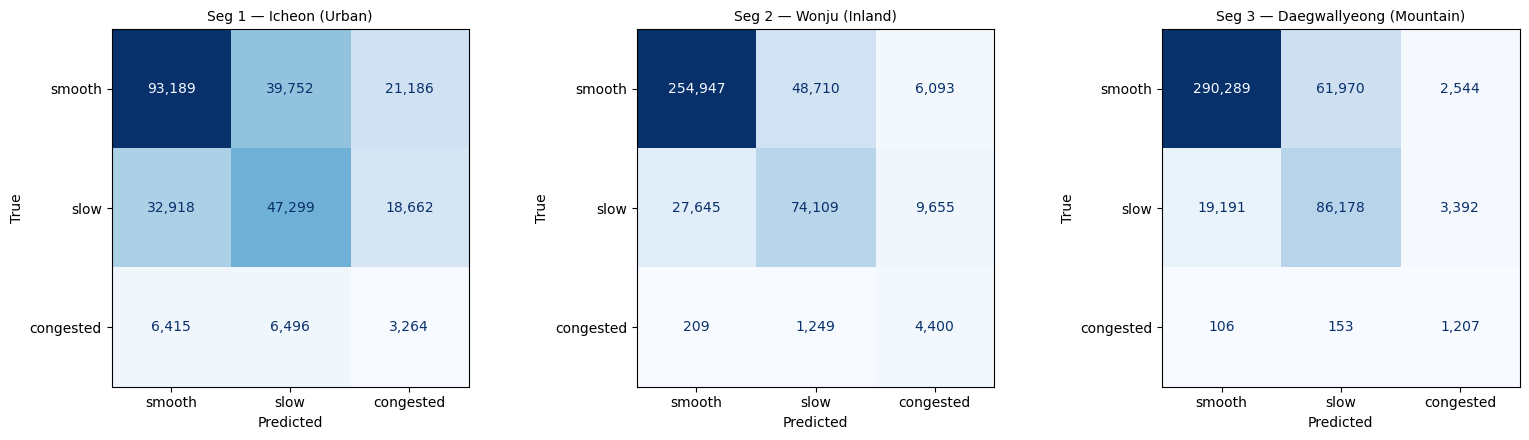

Saved: fig12_confusion_matrices.png

Congested-class recall (caught / total actual congested):
  Seg 1 — Icheon (Urban)            : 3,264/16,175 = 20.2%
  Seg 2 — Wonju (Inland)            : 4,400/5,858 = 75.1%
  Seg 3 — Daegwallyeong (Mountain)  : 1,207/1,466 = 82.3%


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, key in zip(axes, dfs):
    y = data[key]['y']
    cm = confusion_matrix(y, rf_results[key]['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format=',d')
    ax.set_title(SEG_NAMES[key], fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('fig12_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig12_confusion_matrices.png')

# Per-segment recall of the congested class (did we catch real congestion?)
print('\nCongested-class recall (caught / total actual congested):')
for key in dfs:
    y = data[key]['y']; cm = confusion_matrix(y, rf_results[key]['pred'])
    caught, total = cm[2, 2], cm[2].sum()
    print(f'  {SEG_NAMES[key]:<34}: {caught:,}/{total:,} = {caught/total*100:.1f}%')

### 5.3 Full classification reports (Random Forest)

In [7]:
for key in dfs:
    print(f'=== {SEG_NAMES[key]} ===')
    print(classification_report(data[key]['y'], rf_results[key]['pred'],
                                target_names=LABEL_NAMES, digits=3, zero_division=0))

=== Seg 1 — Icheon (Urban) ===
              precision    recall  f1-score   support

      smooth      0.703     0.605     0.650    154127
        slow      0.506     0.478     0.492     98879
   congested      0.076     0.202     0.110     16175

    accuracy                          0.534    269181
   macro avg      0.428     0.428     0.417    269181
weighted avg      0.593     0.534     0.559    269181

=== Seg 2 — Wonju (Inland) ===
              precision    recall  f1-score   support

      smooth      0.902     0.823     0.861    309750
        slow      0.597     0.665     0.629    111409
   congested      0.218     0.751     0.338      5858

    accuracy                          0.781    427017
   macro avg      0.572     0.746     0.609    427017
weighted avg      0.813     0.781     0.793    427017

=== Seg 3 — Daegwallyeong (Mountain) ===
              precision    recall  f1-score   support

      smooth      0.938     0.818     0.874    354803
        slow      0.581   

---
## 6. Feature Importance Comparison — Core Result

This is the project's central question: **do different segments have different
congestion drivers?** We read `feature_importances_` from each segment's Random
Forest and compare side by side.

In [11]:
importance_df = pd.DataFrame(
    {key: rf_models[key].feature_importances_ for key in dfs},
    index=FEATURE_COLS
)
importance_df.columns = [SEG_NAMES[k] for k in dfs]

# Show each segment's ranking
for key in dfs:
    s = pd.Series(rf_models[key].feature_importances_, index=FEATURE_COLS)
    print(f'=== {SEG_NAMES[key]} — top 8 ===')
    print(s.sort_values(ascending=False).head(8).round(3).to_string())
    print()

=== Seg 1 — Icheon (Urban) — top 8 ===
temperature    0.195
visibility     0.164
humidity       0.149
wind_speed     0.134
hour           0.115
dayofweek      0.096
rainfall       0.027
is_weekend     0.022

=== Seg 2 — Wonju (Inland) — top 8 ===
hour                  0.195
temperature           0.139
humidity              0.114
dayofweek             0.109
visibility            0.102
wind_speed            0.086
time_zone_midnight    0.048
is_weekend            0.036

=== Seg 3 — Daegwallyeong (Mountain) — top 8 ===
temperature           0.164
hour                  0.146
visibility            0.140
humidity              0.113
wind_speed            0.108
dayofweek             0.072
snow                  0.045
time_zone_midnight    0.039



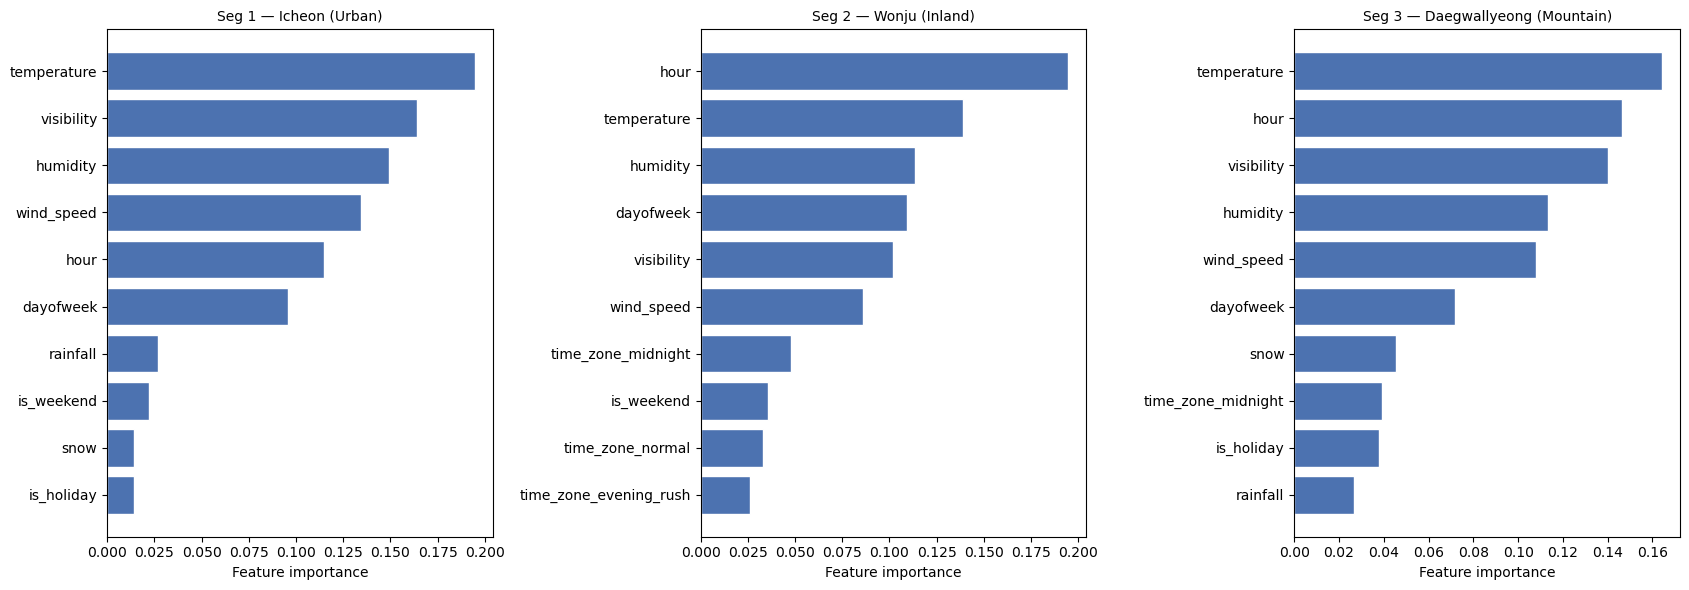

Saved: fig13_feature_importance.png


In [10]:
# Side-by-side horizontal bar chart of top features per segment
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharex=False)
for ax, key in zip(axes, dfs):
    s = pd.Series(rf_models[key].feature_importances_, index=FEATURE_COLS)
    s = s.sort_values(ascending=True).tail(10)
    ax.barh(s.index, s.values, color='#4C72B0', edgecolor='white')
    ax.set_title(SEG_NAMES[key], fontsize=10)
    ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.savefig('fig13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig13_feature_importance.png')

### 6.1 Observation — hypothesis vs. measured result

The EDA stage *hypothesised* (from visual inspection):
- Urban (seg1) would be **time-dominated** (rush-hour effect)
- Mountain (seg3) would be **snow-dominated**

The fitted Random Forests show a **different picture** — read the printed rankings
above and fill in for the presentation:

- In every segment, **weather features** (temperature, visibility, humidity)
  rank at or near the top, often above `hour`.
- `snow` does **not** dominate the mountain segment, despite the EDA snow–congestion
  link. A likely reason: snow is zero for the vast majority of hours, so even after
  standardisation it carries little splitting information, while `temperature`
  indirectly encodes both season and time-of-day.

This gap between the EDA hypothesis and the model result is itself a finding — it is
exactly what supervised modeling is for, and it feeds directly into the
*Results & Interpretation* and *Limitations* sections of the presentation.
**Do not present the EDA hypothesis as the conclusion; present the measured
importances as the conclusion.**

---
## 7. Limitations & Future Work

**Limitations**
- **Extreme class imbalance.** `congested` is only 0.3% in seg3 (1,466 rows).
  Even with `class_weight='balanced'`, the congested-class F1 is low (precision
  suffers from false alarms), so congestion estimates for the mountain segment are
  the least reliable.
- **Weak natural cluster separation.** Team Member 2's silhouette scores (~0.17–0.19)
  already showed that time+weather features overlap heavily — the supervised models
  inherit this difficulty.
- **One direction only.** Only the VDE (Gangneung-bound) direction was used; the
  opposite direction may have different congestion patterns.
- **Narrow spatial window.** Only ±10 km around each weather station was used, so
  results may not generalise to the full 232 km highway or to other routes.
- **No real-time / temporal features.** Speed, volume, and occupancy were excluded
  by design to avoid leakage, and no lag features were used, so the model cannot
  exploit short-term momentum (a congestion at *t-1* predicting *t*).

**Future work**
- Add real-time speed/volume as *lagged* features (e.g. t-1, t-2) to build a true
  short-horizon forecaster, while keeping the leakage-free model as a baseline.
- Use both directions and the full highway length.
- Try gradient-boosted trees (XGBoost / LightGBM) and compare importances.
- Threshold tuning / cost-sensitive learning to improve congested-class precision.


---
## 8. Output Files
| File | Description |
|---|---|
| `fig12_confusion_matrices.png` | RF confusion matrices, 3 segments |
| `fig13_feature_importance.png` | Feature importance comparison, 3 segments |

> Place this notebook in the `notebooks/` folder alongside `eda_kmeans_team2.ipynb`
> so the relative path `../data/` resolves correctly.